<a href="https://colab.research.google.com/github/JBrunoLLeao/CNN-Mobile/blob/main/Colab/CNNMobileSegmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone https://github.com/JBrunoLLeao/CNN-Mobile
!cp CNNMobile.ipynb repo/colab/
!cd repo && git add . && git commit -m "add colab" && git push

Cloning into 'CNN-Mobile'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (131/131), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 131 (delta 10), reused 122 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (131/131), 37.03 MiB | 11.94 MiB/s, done.
Resolving deltas: 100% (10/10), done.
cp: cannot stat 'CNNMobile.ipynb': No such file or directory
/bin/bash: line 1: cd: repo: No such file or directory


In [ ]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install torchmetrics
!pip install opencv-python
!pip install matplotlib
!pip install tqdm

Looking in indexes: https://download.pytorch.org/whl/cu118
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 29.4 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import torchmetrics

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

In [ ]:
# -- PARÂMETROS GLOBAIS --
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Parâmetros do dataset e treinamento
DATA_DIR = "./data"
IMAGE_SIZE = 128
BATCH_SIZE = 16
NUM_CLASSES = 3  # Oxford Pet: 0 (Pet), 1 (Fundo), 2 (Borda)
LEARNING_RATE = 0.001
NUM_EPOCHS = 5

# Dataset reduzido para treino
NUM_TRAIN_SAMPLES = 800
NUM_VAL_SAMPLES = 200

print(f"Device: {DEVICE}")

Device: cuda


In [ ]:
# Transforms nas imagens
image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Transforms nas masks
target_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor(),
])

def process_target(target):
    target = torch.squeeze(target)
    # Valores originais usam 1-index
    # CrossEntropyLoss usa 0-index
    target = target - 1
    return target.long()

# Carregando o dataset
full_dataset = datasets.OxfordIIITPet(
    root=DATA_DIR,
    split="trainval",
    target_types="segmentation",
    download=True,
    transform=image_transform,
    target_transform=lambda t: process_target(target_transform(t))
)

# Subsets reduzidos para treino e validação por index
indices = torch.randperm(len(full_dataset)).tolist()
train_dataset = Subset(full_dataset, indices[:NUM_TRAIN_SAMPLES])
val_dataset = Subset(full_dataset, indices[NUM_TRAIN_SAMPLES:NUM_TRAIN_SAMPLES + NUM_VAL_SAMPLES])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Total: {len(train_dataset)} imagens de treino e {len(val_dataset)} de validação.")

100%|██████████| 792M/792M [00:29<00:00, 26.4MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.3MB/s]


Total: 800 imagens de treino e 200 de validação.


In [ ]:
# Bloco de convolução duplo, base da U-Net
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=NUM_CLASSES, features=[64, 128]):
        super(SimpleUNet, self).__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Encoder
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # Decoder
        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature * 2, feature))

        # Bottleneck e final
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        # Encoder
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        # Decoder
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx // 2]

            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx + 1](concat_skip)

        return self.final_conv(x)

In [ ]:
unet_model = SimpleUNet(
    in_channels=3,
    out_channels=NUM_CLASSES
)

print(unet_model)

SimpleUNet(
  (ups): ModuleList(
    (0): ConvTranspose2d(256, 128, kernel_size=(2, 2), stride=(2, 2))
    (1): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (2): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (3): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), pa

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    unet_model.parameters(),
    lr=LEARNING_RATE
)

print("Loss:", criterion)
print("Optimizer:", optimizer)

Loss: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    model.to(DEVICE)
    best_loss = float('inf')

    for epoch in range(num_epochs):
        start_time = time.time()

        model.train()
        running_loss = 0.0
        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(images)
            if isinstance(outputs, dict): # FCN() -> dict
                outputs = outputs['out']

            loss = criterion(outputs, masks)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
                images = images.to(DEVICE)
                masks = masks.to(DEVICE)

                outputs = model(images)
                if isinstance(outputs, dict):
                    outputs = outputs['out']

                loss = criterion(outputs, masks)
                val_loss += loss.item() * images.size(0)

        val_loss = val_loss / len(val_loader.dataset)

        end_time = time.time()
        epoch_duration = end_time - start_time

        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Duração: {epoch_duration:.2f}s - "
              f"Train Loss: {epoch_loss:.4f} - "
              f"Val Loss: {val_loss:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), f"{model.__class__.__name__}_best.pth")
            print(f"  -> Modelo salvo com a melhor val loss: {best_loss:.4f}")

    return model

In [ ]:
print("Training : U-Net")

unet_model = SimpleUNet(
    in_channels=3,
    out_channels=NUM_CLASSES
)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    unet_model.parameters(),
    lr=LEARNING_RATE
)

trained_unet = train_model(
    unet_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    NUM_EPOCHS
)

Training : U-Net


Epoch 1/5 [Val]: 100%|██████████| 13/13 [00:01<00:00,  8.80it/s]


Epoch 1/5 - Duração: 13.03s - Train Loss: 0.8434 - Val Loss: 0.8291
  -> Modelo salvo com a melhor val loss: 0.8291


Epoch 2/5 [Val]: 100%|██████████| 13/13 [00:01<00:00,  9.16it/s]


Epoch 2/5 - Duração: 11.53s - Train Loss: 0.6838 - Val Loss: 0.7388
  -> Modelo salvo com a melhor val loss: 0.7388


...

Epoch 3/5 - Duração: 11.64s - Train Loss: 0.6384 - Val Loss: 0.7406


Epoch 4/5 [Val]: 100%|██████████| 13/13 [00:01<00:00,  9.01it/s]


Epoch 4/5 - Duração: 12.34s - Train Loss: 0.6352 - Val Loss: 0.6337
  -> Modelo salvo com a melhor val loss: 0.6337


Epoch 5/5 [Val]: 100%|██████████| 13/13 [00:01<00:00,  8.01it/s]

Epoch 5/5 - Duração: 11.77s - Train Loss: 0.5958 - Val Loss: 0.6721


In [ ]:
# ------------ FCN-ResNet50
print("Training : FCN-ResNet50")
fcn_model = models.segmentation.fcn_resnet50(weights=models.segmentation.FCN_ResNet50_Weights.DEFAULT)
# original: varias classes
# nosso dataset: 3 classes
fcn_model.classifier[4] = nn.Conv2d(512, NUM_CLASSES, kernel_size=(1, 1), stride=(1, 1))

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(fcn_model.parameters(), lr=LEARNING_RATE)

trained_fcn = train_model(fcn_model, train_loader, val_loader, criterion, optimizer, NUM_EPOCHS)

Training : FCN-ResNet50
Downloading: "https://download.pytorch.org/models/fcn_resnet50_coco-1167a1af.pth" to /root/.cache/torch/hub/checkpoints/fcn_resnet50_coco-1167a1af.pth


100%|██████████| 135M/135M [00:01<00:00, 107MB/s]
Epoch 1/5 [Val]: 100%|██████████| 13/13 [00:01<00:00,  7.61it/s]


Epoch 1/5 - Duração: 16.15s - Train Loss: 0.5360 - Val Loss: 0.4416
  -> Modelo salvo com a melhor val loss: 0.4416


Epoch 2/5 [Val]: 100%|██████████| 13/13 [00:01<00:00,  7.36it/s]


Epoch 2/5 - Duração: 16.12s - Train Loss: 0.3789 - Val Loss: 0.4338
  -> Modelo salvo com a melhor val loss: 0.4338


...

Epoch 3/5 - Duração: 16.15s - Train Loss: 0.3372 - Val Loss: 0.4183
  -> Modelo salvo com a melhor val loss: 0.4183


Epoch 4/5 [Val]: 100%|██████████| 13/13 [00:01<00:00,  7.19it/s]


Epoch 4/5 - Duração: 16.21s - Train Loss: 0.2959 - Val Loss: 0.3552
  -> Modelo salvo com a melhor val loss: 0.3552


Epoch 5/5 [Val]: 100%|██████████| 13/13 [00:01<00:00,  6.84it/s]


Epoch 5/5 - Duração: 16.59s - Train Loss: 0.2700 - Val Loss: 0.3360
  -> Modelo salvo com a melhor val loss: 0.3360


In [ ]:
def calculate_iou_manual(preds, targets, num_classes):
    preds = torch.argmax(preds, dim=1)

    preds = preds.view(-1)
    targets = targets.view(-1)

    iou_per_class = []
    for cls in range(num_classes):
        pred_inds = (preds == cls)
        target_inds = (targets == cls)

        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()

        if union == 0:
            iou = 1.0
        else:
            iou = intersection / union

        iou_per_class.append(iou)

    return np.mean(iou_per_class)

def evaluate_minibatch(model, loader):
    model.eval()
    model.to(DEVICE)

    # usando torchmetrics
    # jaccard: IoU
    jaccard = torchmetrics.JaccardIndex(task="multiclass", num_classes=NUM_CLASSES, average='macro').to(DEVICE)
    accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=NUM_CLASSES, average='macro').to(DEVICE)

    with torch.no_grad():
        # um batch de validation
        images, masks = next(iter(loader))
        images, masks = images.to(DEVICE), masks.to(DEVICE)

        outputs = model(images)
        if isinstance(outputs, dict):
            outputs = outputs['out']

        # metrica
        iou_manual = calculate_iou_manual(outputs, masks, NUM_CLASSES)

        # metricas com torchmetrics
        tm_iou = jaccard(outputs, masks)
        tm_acc = accuracy(outputs, masks)

        print(f"--- Avaliação de um Minibatch para '{model.__class__.__name__}' ---")
        print(f"IoU (medio) calculado manualmente: {iou_manual:.4f}")
        print(f"IoU (medio) com Torchmetrics:     {tm_iou.item():.4f}")
        print(f"Acurácia (media) com Torchmetrics: {tm_acc.item():.4f}\n")

evaluate_minibatch(trained_unet, val_loader)
evaluate_minibatch(trained_fcn, val_loader)

--- Avaliação de um Minibatch para 'SimpleUNet' ---
IoU (medio) calculado manualmente: 0.4823
IoU (medio) com Torchmetrics:     0.4823
Acurácia (media) com Torchmetrics: 0.6118

--- Avaliação de um Minibatch para 'FCN' ---
IoU (medio) calculado manualmente: 0.6320
IoU (medio) com Torchmetrics:     0.6320
Acurácia (media) com Torchmetrics: 0.7392



In [ ]:
# Utils para visualização

def unnormalize_image(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

def mask_to_rgb(mask, num_classes=NUM_CLASSES):
    colors = torch.tensor([
        [255, 0, 0],    # 0 (Pet) = Red
        [0, 255, 0],    # 1 (Fundo) = Green
        [0, 0, 255]     # 2 (Borda) = Blue
    ], dtype=torch.uint8)

    rgb_mask = torch.zeros(mask.size(0), mask.size(1), 3, dtype=torch.uint8)
    for cls in range(num_classes):
        rgb_mask[mask == cls] = colors[cls]

    return rgb_mask.numpy()


def visualize_predictions(model, loader, num_images=5):
    model.eval()
    model.to(DEVICE)

    images, masks = next(iter(loader))
    images, masks = images.to(DEVICE), masks.to(DEVICE)

    with torch.no_grad():
        outputs = model(images)
        if isinstance(outputs, dict):
            outputs = outputs['out']
        preds = torch.argmax(outputs, dim=1)

    images = images.cpu()
    masks = masks.cpu()
    preds = preds.cpu()

    plt.figure(figsize=(15, num_images * 5))
    plt.suptitle(f"Resultados para {model.__class__.__name__}", fontsize=16)

    for i in range(num_images):
        # Original
        ax = plt.subplot(num_images, 3, i * 3 + 1)
        img = unnormalize_image(images[i])
        plt.imshow(img.permute(1, 2, 0))
        ax.set_title("Imagem Original")
        ax.axis("off")

        # Mask Ground Truth
        ax = plt.subplot(num_images, 3, i * 3 + 2)
        gt_mask_rgb = mask_to_rgb(masks[i])
        plt.imshow(gt_mask_rgb)
        ax.set_title("Máscara Real (GT)")
        ax.axis("off")

        # Mask preds
        ax = plt.subplot(num_images, 3, i * 3 + 3)
        pred_mask_rgb = mask_to_rgb(preds[i])
        plt.imshow(pred_mask_rgb)
        ax.set_title("Predição do Modelo")
        ax.axis("off")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def compare_models(model1, model2, loader, num_images=5):
    model1.eval().to(DEVICE)
    model2.eval().to(DEVICE)

    images, masks = next(iter(loader))
    images, masks = images.to(DEVICE), masks.to(DEVICE)

    with torch.no_grad():
        # UNet
        out1 = model1(images)
        if isinstance(out1, dict): out1 = out1['out']
        preds1 = torch.argmax(out1, dim=1)

        # FCN
        out2 = model2(images)
        if isinstance(out2, dict): out2 = out2['out']
        preds2 = torch.argmax(out2, dim=1)

    images, masks, preds1, preds2 = images.cpu(), masks.cpu(), preds1.cpu(), preds2.cpu()

    plt.figure(figsize=(20, num_images * 5))
    plt.suptitle("Comparação de Modelos: U-Net vs FCN-ResNet50", fontsize=16)

    for i in range(num_images):
        # Original
        ax = plt.subplot(num_images, 4, i * 4 + 1)
        plt.imshow(unnormalize_image(images[i]).permute(1, 2, 0))
        ax.set_title("Original")
        ax.axis("off")

        # Ground Truth
        ax = plt.subplot(num_images, 4, i * 4 + 2)
        plt.imshow(mask_to_rgb(masks[i]))
        ax.set_title("Ground Truth")
        ax.axis("off")

        # Pred UNet
        ax = plt.subplot(num_images, 4, i * 4 + 3)
        plt.imshow(mask_to_rgb(preds1[i]))
        ax.set_title("Pred UNet")
        ax.axis("off")

        # Predição FCN
        ax = plt.subplot(num_images, 4, i * 4 + 4)
        plt.imshow(mask_to_rgb(preds2[i]))
        ax.set_title("Pred FCN")
        ax.axis("off")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [ ]:
trained_unet.load_state_dict(
    torch.load("SimpleUNet_best.pth")
)

print("Modelo carregado")

Modelo carregado


--- Visualizando Preds da U-Net ---


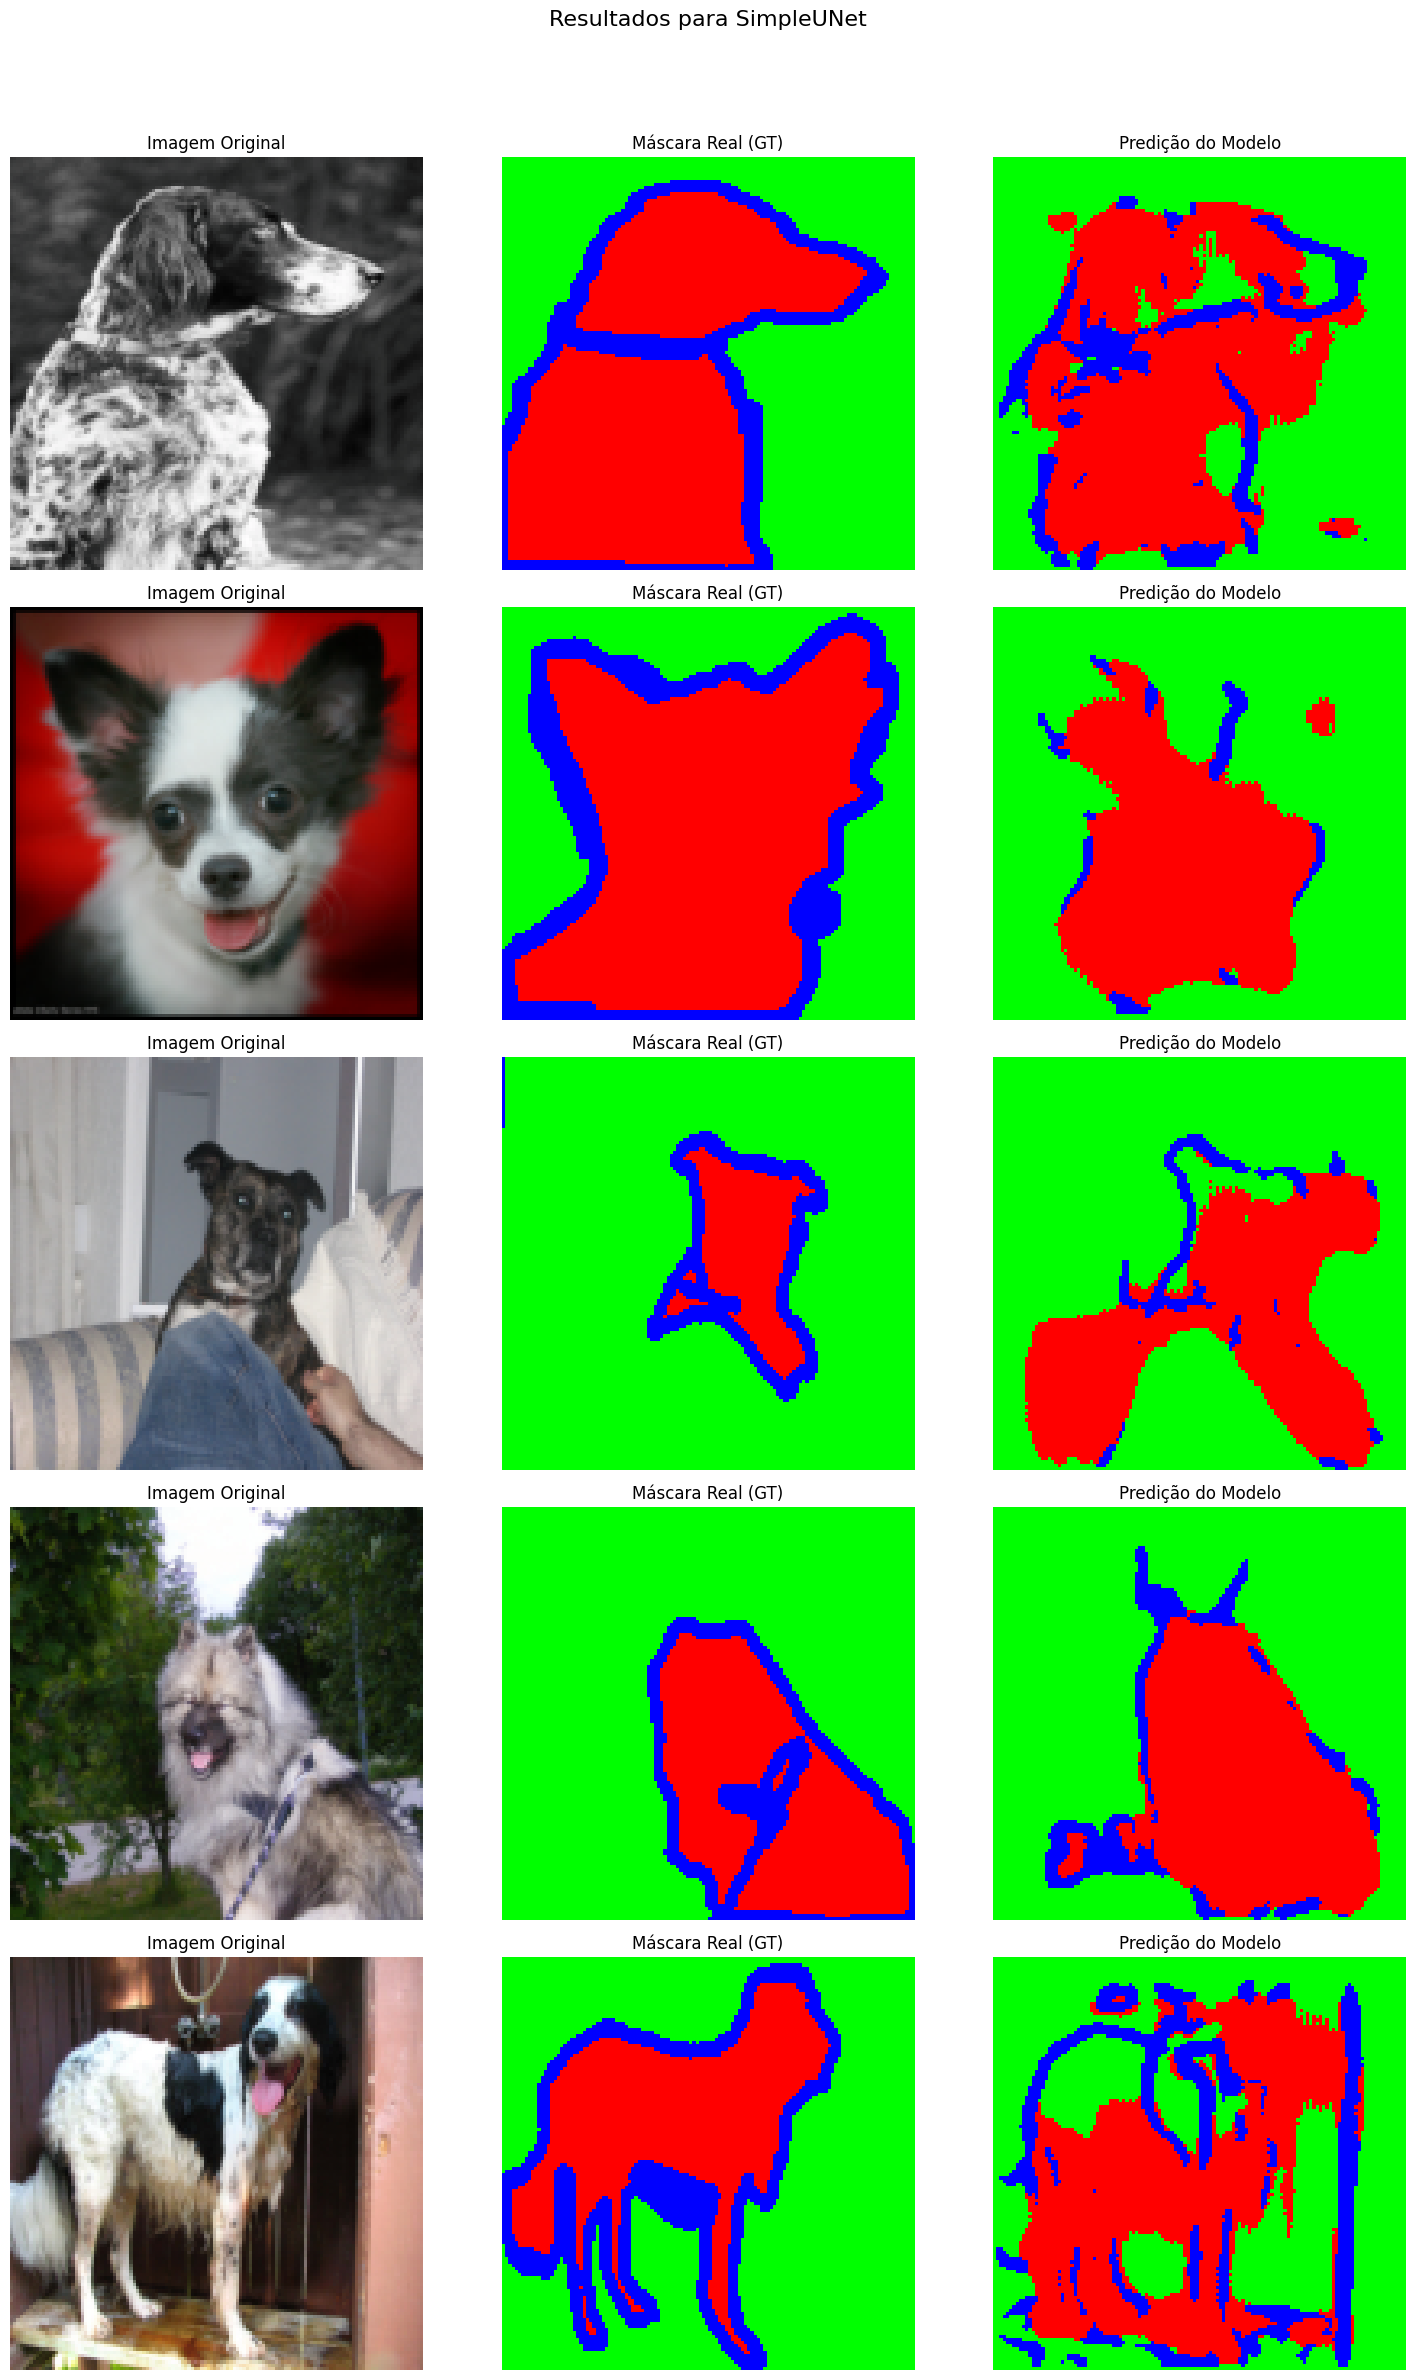


--- Visualizando Preds da FCN-ResNet50 ---


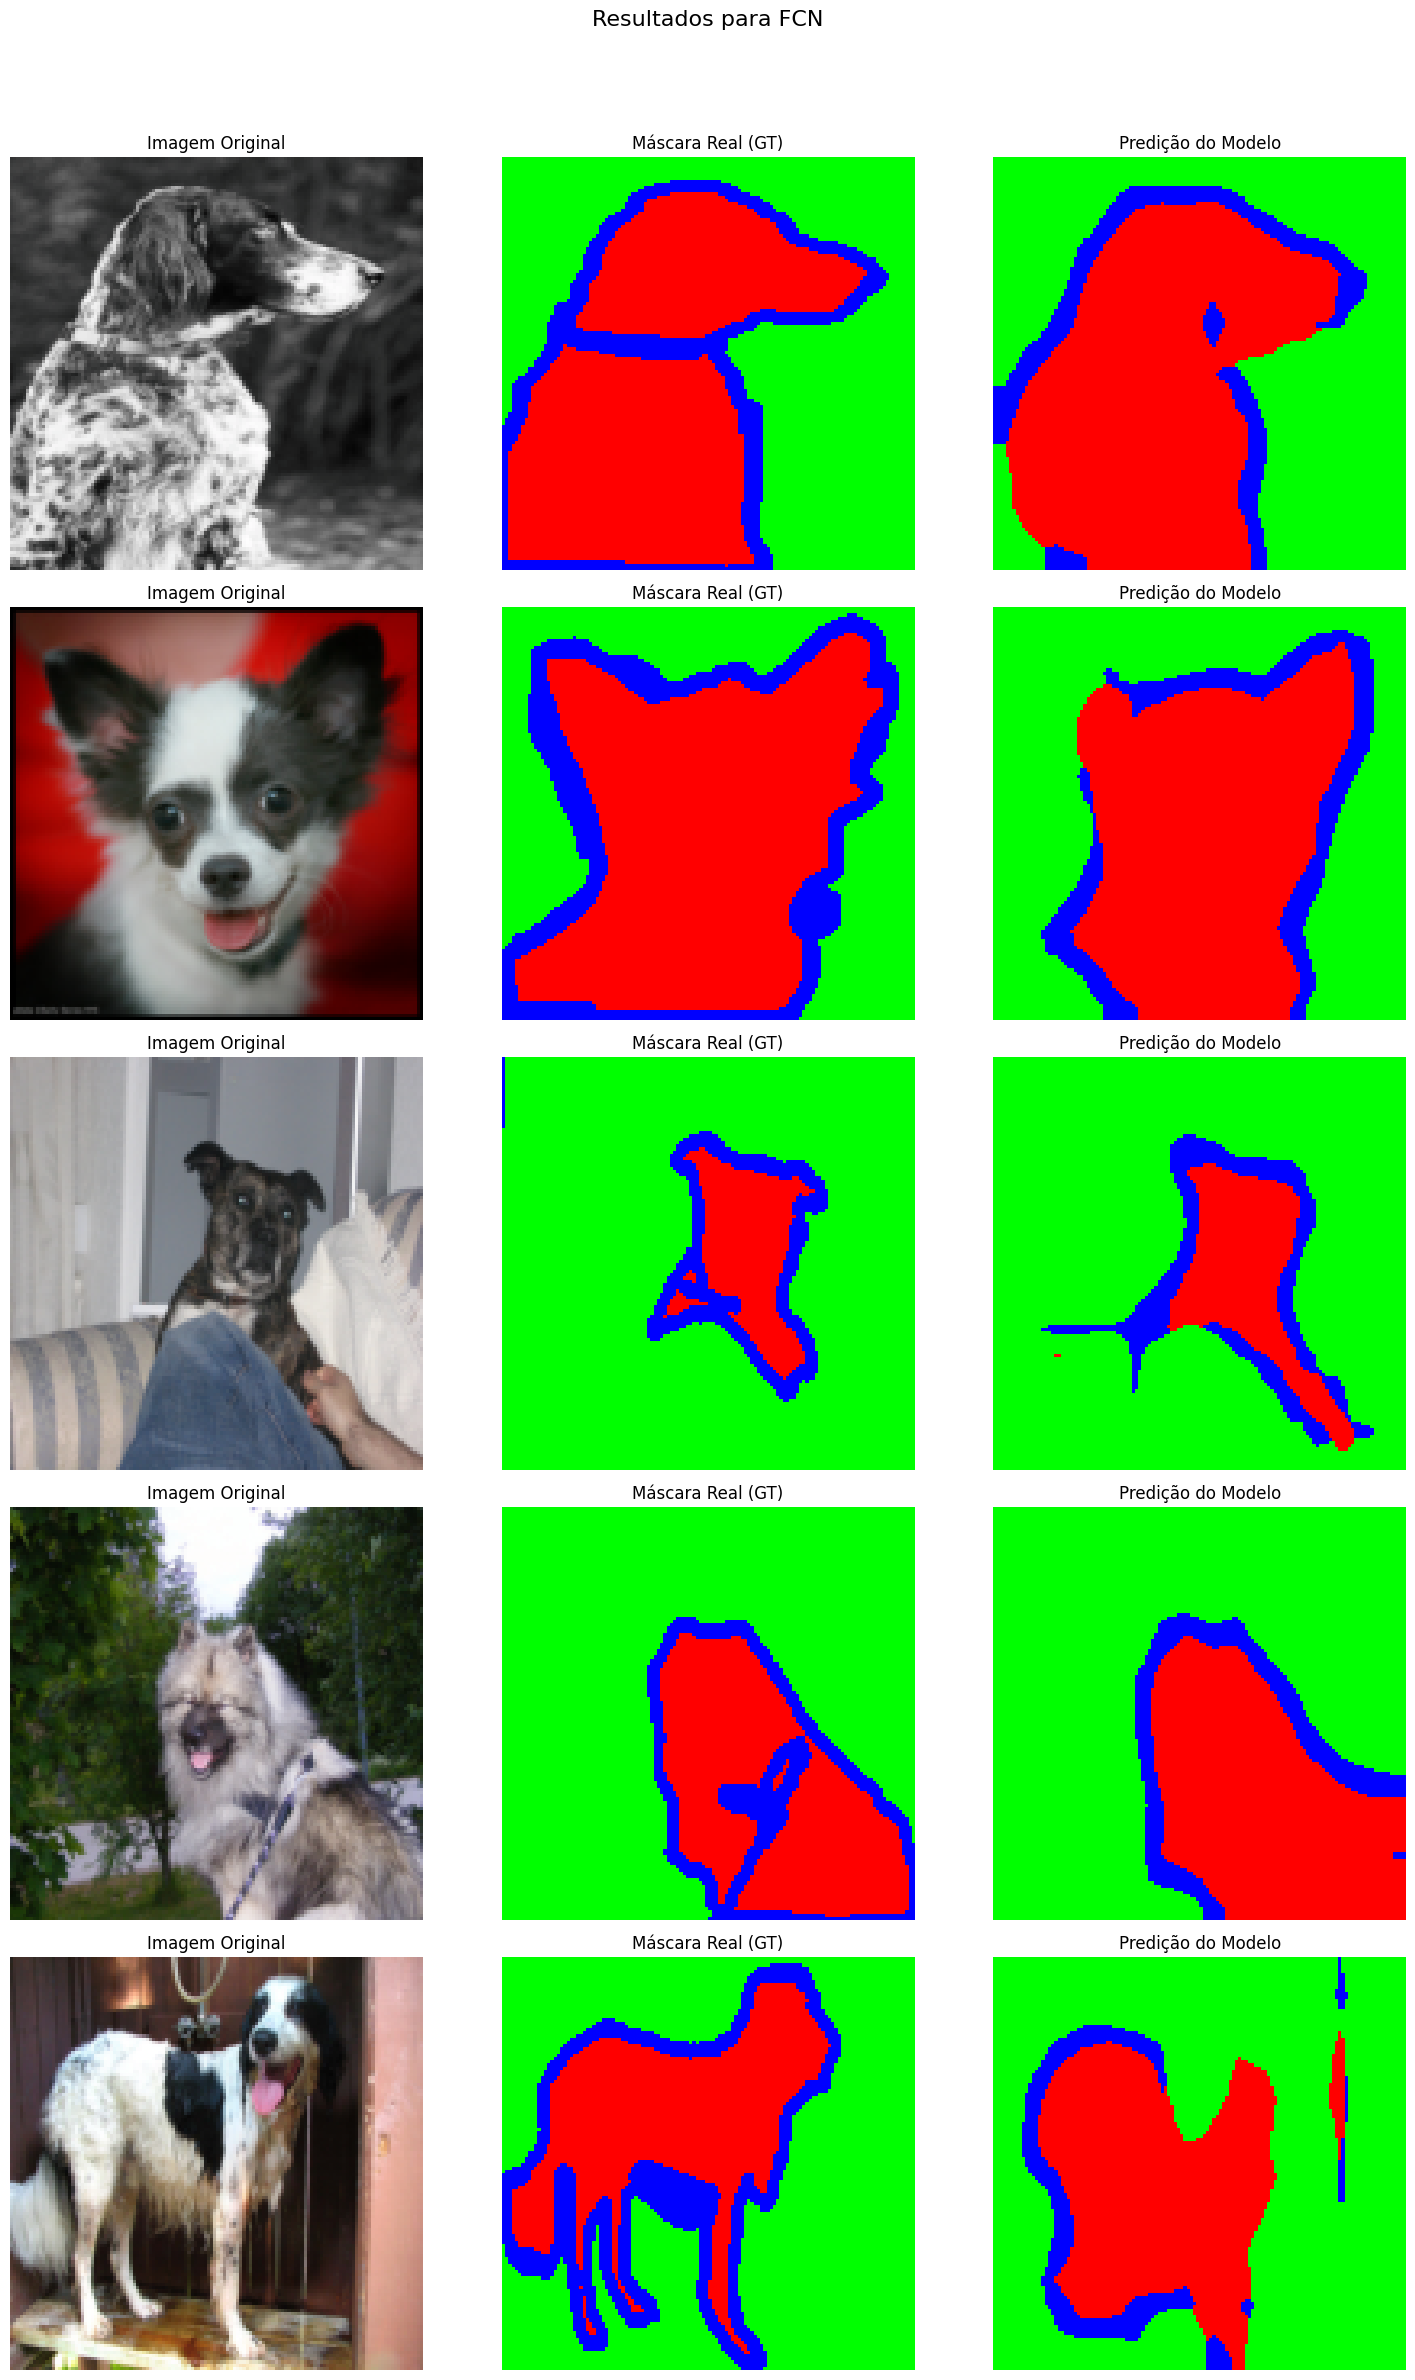


--- Comparando Modelos Lado a Lado ---


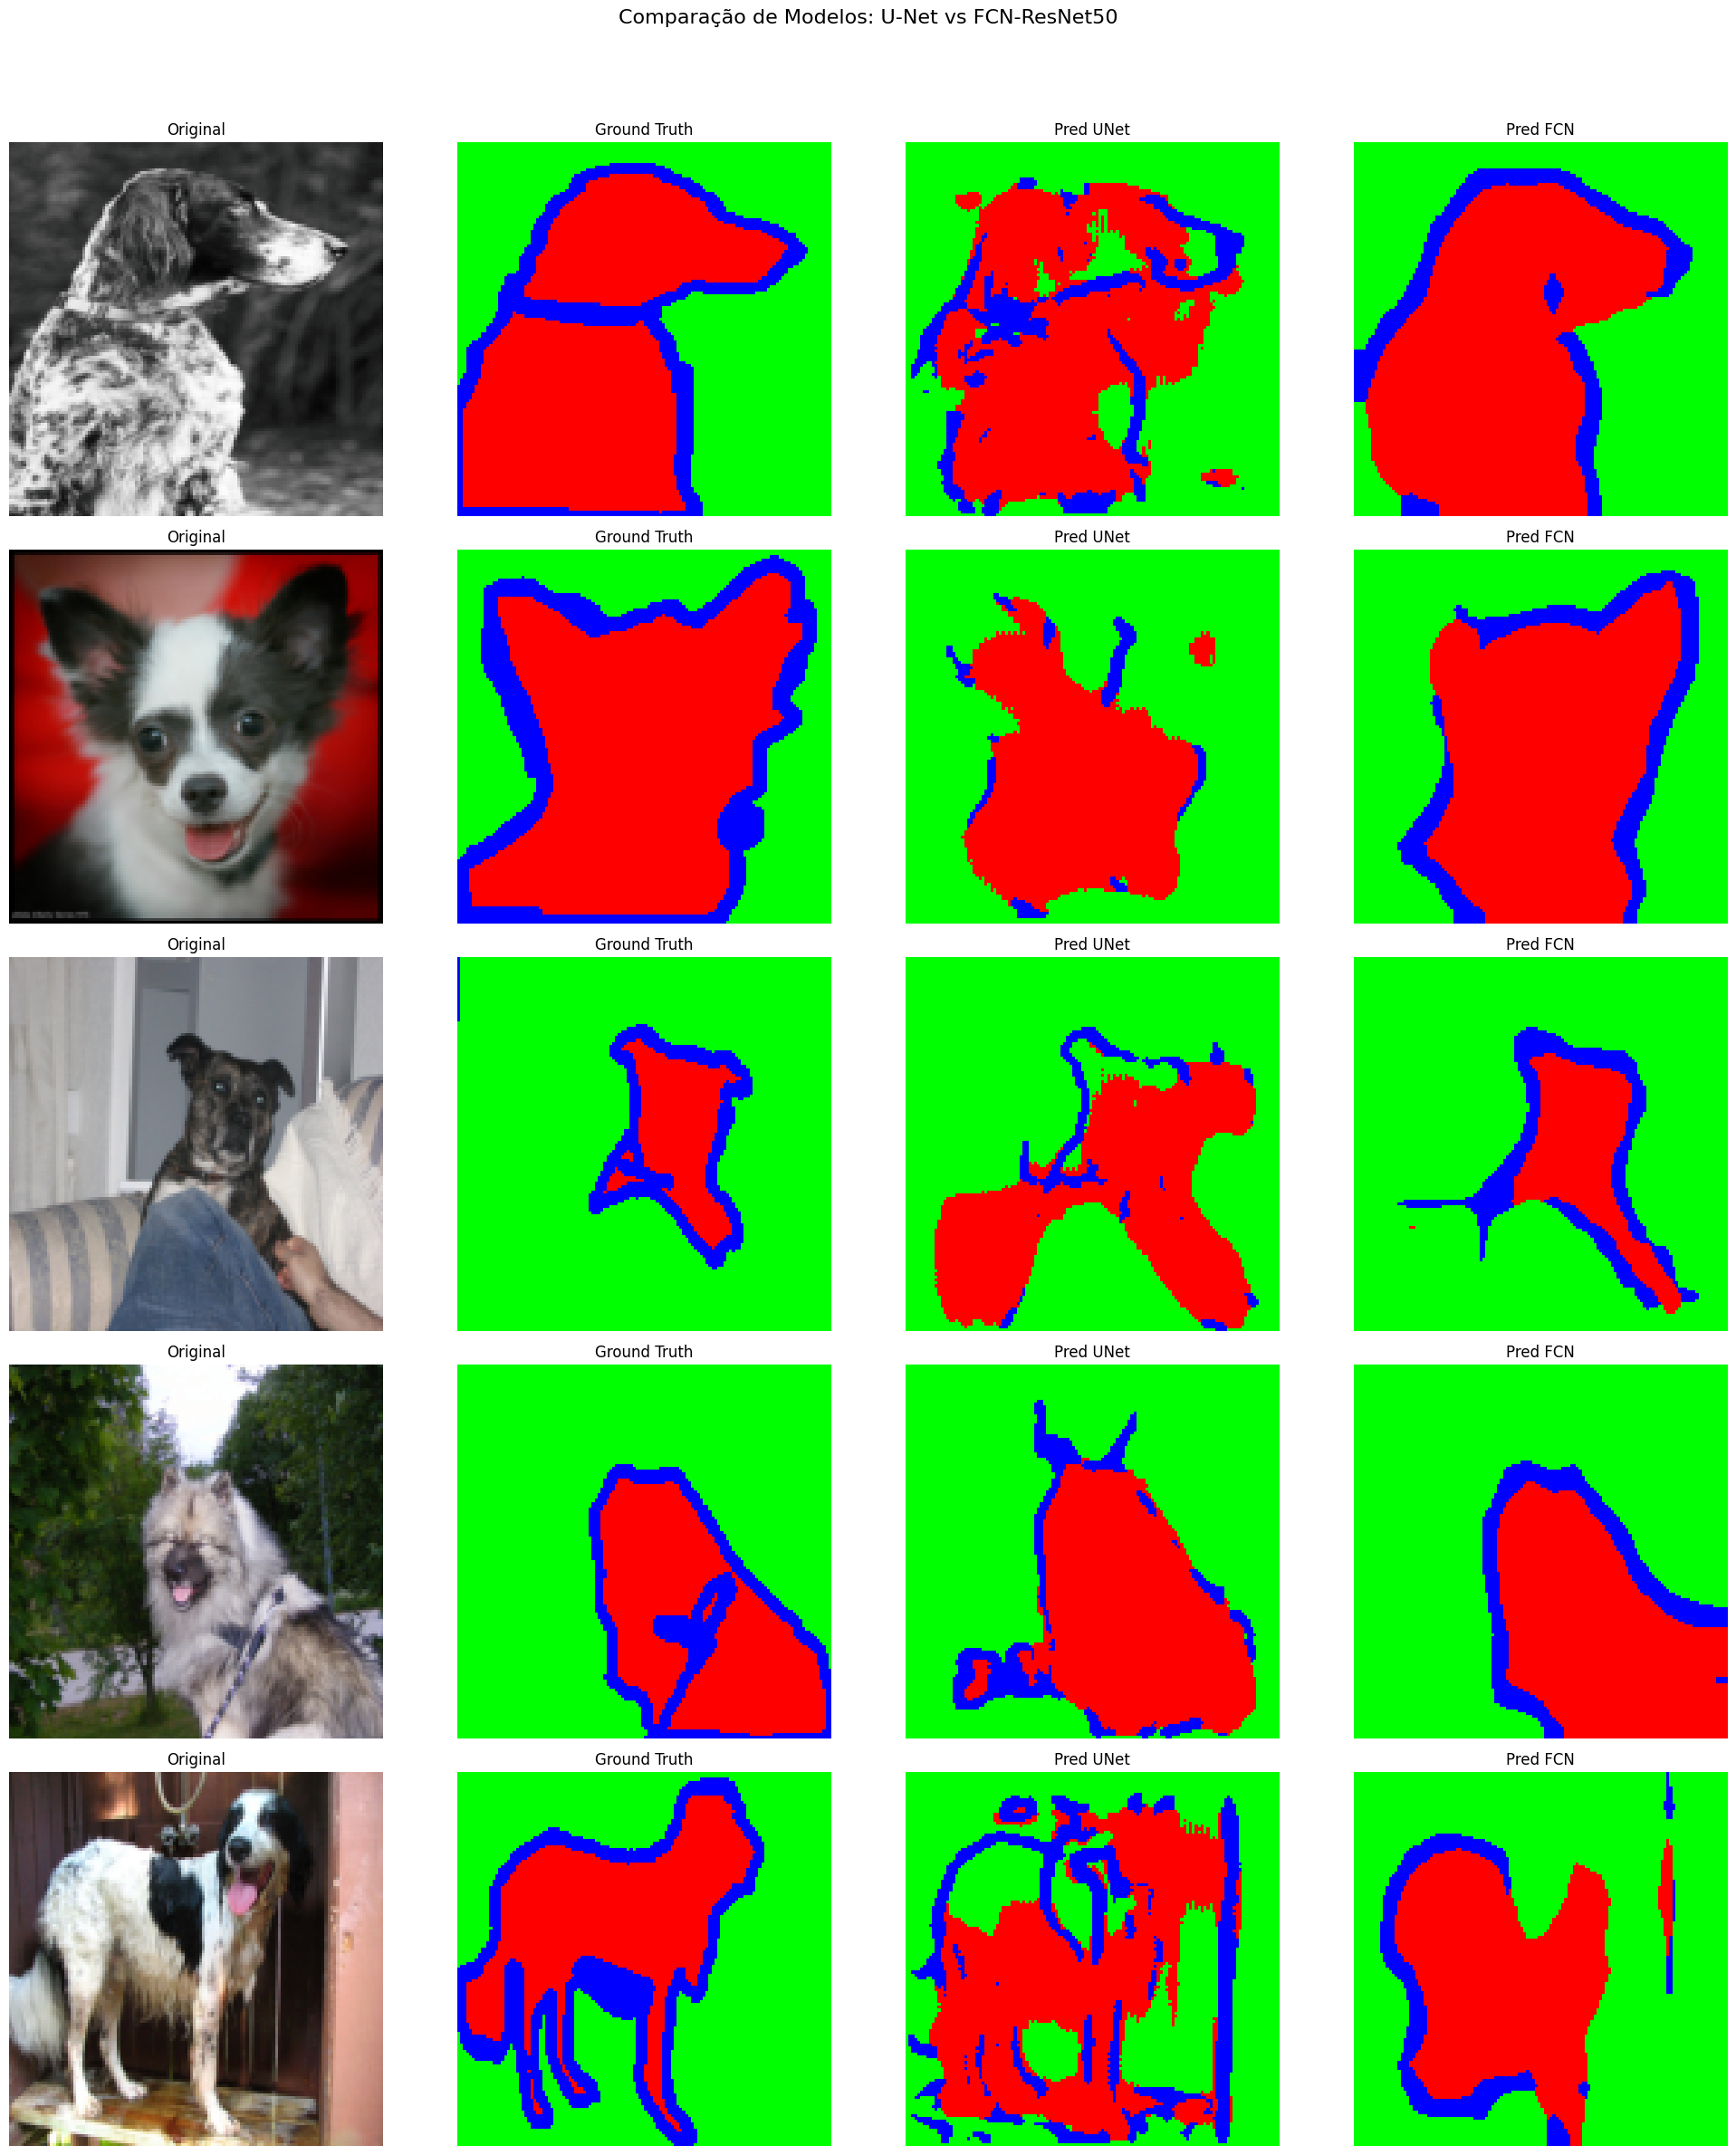

In [ ]:
# Carregando os melhores pesos salvos durante o treino para garantir a melhor visualização
trained_unet.load_state_dict(torch.load("SimpleUNet_best.pth"))
trained_fcn.load_state_dict(torch.load("FCN_best.pth"))

# Visualizando os resultados da U-Net
print("--- Visualizando Preds da U-Net ---")
visualize_predictions(trained_unet, val_loader)

# Visualizando os resultados da FCN
print("\n--- Visualizando Preds da FCN-ResNet50 ---")
visualize_predictions(trained_fcn, val_loader)

# Comparando os modelos
print("\n--- Comparando Modelos Lado a Lado ---")
compare_models(trained_unet, trained_fcn, val_loader)

In [ ]:
!pip install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 21.2 MB/s eta 0:00:00


In [ ]:
#modelo em modo de inferência
trained_unet.eval()

# Entrada fictícia com o mesmo tamanho usado no treino
# (1 imagem, 3 canais, 128x128)
dummy_input = torch.randn(1, 3, 128, 128).to(DEVICE)

# Exporta para ONNX
torch.onnx.export(
    trained_unet,
    dummy_input,
    "unet_pet.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=11
)


W0605 01:26:48.788000 755 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `SimpleUNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SimpleUNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.11.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,3,128,128]>
            ),
            outputs=(
                %"output"<FLOAT,[1,3,128,128]>
            ),
            initializers=(
                %"ups.0.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"ups.2.bias"<FLOAT,[64]>{TorchTensor(...)},
                %"final_conv.weight"<FLOAT,[3,64,1,1]>{TorchTensor(...)},
                %"final_conv.bias"<FLOAT,[3]>{TorchTensor<FLOAT,[3]>(Parameter containing: tensor([ 0.0528,  0.0842, -0.0141], device='cuda:0', requires_grad=True), name='final_conv.bias')},
                %"ups.0.weight"<FLOAT,[256,128,2,2]>{TorchTensor(...)},
                %"ups.1.conv.0.weight"<FLOAT,[128,256,3,3

In [ ]:
import onnx

model = onnx.load("unet_pet.onnx")
onnx.checker.check_model(model)

print("ONNX válido!")

ONNX válido!


In [ ]:
!pip install onnx-tf
!pip install tensorflow

In [ ]:
!pip show onnx
!pip show tensorflow

In [ ]:
import onnx

model = onnx.load("unet_pet.onnx")

for inp in model.graph.input:
    shape = [d.dim_value for d in inp.type.tensor_type.shape.dim]
    print("INPUT:", inp.name, shape)

for out in model.graph.output:
    shape = [d.dim_value for d in out.type.tensor_type.shape.dim]
    print("OUTPUT:", out.name, shape)

INPUT: input [1, 3, 128, 128]
OUTPUT: output [1, 3, 128, 128]


In [ ]:
import onnx

model = onnx.load("unet_pet.onnx")

ops = {}

for node in model.graph.node:
    ops[node.op_type] = ops.get(node.op_type, 0) + 1

print("Operadores encontrados:\n")

for k, v in sorted(ops.items()):
    print(f"{k}: {v}")

Operadores encontrados:

Concat: 2
Conv: 11
ConvTranspose: 2
MaxPool: 2
Relu: 10


In [ ]:
!pip install -q onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 102.2 MB/s eta 0:00:00


In [ ]:
import onnxruntime as ort
import numpy as np

sess = ort.InferenceSession("unet_pet.onnx")

print("Inputs:")
for i in sess.get_inputs():
    print(i.name, i.shape, i.type)

print("\nOutputs:")
for o in sess.get_outputs():
    print(o.name, o.shape, o.type)

x = np.random.randn(1,3,128,128).astype(np.float32)

y = sess.run(None, {"input": x})

print("\nOutput shape:")
print(y[0].shape)

Inputs:
input [1, 3, 128, 128] tensor(float)

Outputs:
output [1, 3, 128, 128] tensor(float)

Output shape:
(1, 3, 128, 128)


In [ ]:
!pip install -q onnx2tf

In [ ]:
import onnx2tf
print("onnx2tf instalado com sucesso")

onnx2tf instalado com sucesso


In [ ]:
!onnx2tf -i unet_pet.onnx -o tf_unet


Model optimizing started ============================================================
Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃               ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Concat        │ 2              │ 2                │
│ Constant      │ 26             │ 26               │
│ Conv          │ 11             │ 11               │
│ ConvTranspose │ 2              │ 2                │
│ MaxPool       │ 2              │ 2                │
│ Relu          │ 10             │ 10               │
│ Model Size    │ 7.1MiB         │ 7.1MiB           │
└───────────────┴────────────────┴──────────────────┘

Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃               ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Concat        │ 2              │ 2                │
│ Consta